# FABN Portfolio Optimizer — SAP Statutory Objective  *(Phase 1, single-period)*

Under **Statutory Accounting Principles (SAP)**, bonds are held at **amortized cost** — value is created through **book-yield earnings per unit of required capital**, not market appreciation.

$$
\max_{h,v}\;\Big(
\underbrace{\sum_i (y_i - r^{FABN})\,h_i}_{\text{Bond NII}}
+\underbrace{r_{save}\,\Delta t\sum_q B_q}_{\text{Facility income}}
+\underbrace{\sum_k(c_k - r^{float})\,v_k}_{\text{Swap NII}}
-\underbrace{\lambda\sum_i\theta_i\,h_i}_{\text{Bond capital}}
-\underbrace{\lambda\mu\sum_k v_k}_{\text{Swap capital}}
-\underbrace{\eta\sum_q DF_q\, s^{net}_q}_{\text{Liquidity penalty}}
-\underbrace{\sum_i\tau_i(tc^+_i + tc^-_i)}_{\text{Turnover}}
\Big)
$$

| Term | Formula | Description |
|---|---|---|
| Bond NII | $\sum_i(y_i - r^{FABN})\,h_i$ | Book yield (coupon + amortization) net of FABN funding rate |
| Facility income | $r_{save}\,\Delta t\sum_q B_q$ | Reinvestment income earned on lending-facility surplus each quarter |
| Swap NII | $\sum_k(c_k - r^{float})\,v_k$ | Receive-fixed net income; positive when fixed rate $c_k >$ SOFR |
| Bond capital cost | $\lambda_{cap}\sum_i\theta_i h_i$ | C-1 RBC charge on bonds; $\lambda_{cap}$ = cost\_of\_capital × RBC\_bar |
| Swap capital cost | $\lambda_{cap}\,\mu\sum_k v_k$ | C-3 RBC charge on swap notional |
| Liquidity penalty | $\eta\sum_q DF_q\, s^{net}_q$ | PV of quarterly cash shortfalls in the lending facility |
| Turnover cost | $\sum_i\tau_i(tc^+_i + tc^-_i)$ | Actual bid-ask half-spread on buys ($tc^+$) and sells ($tc^-$) |

**Constraints:** budget $\sum h_i = H$; duration band $\bigl|\sum D_i h_i + \sum D^{sw}_k v_k - D^{FABN}H\bigr|\le\varepsilon_D H$; issuer cap $\le 5\%\cdot H$; quarterly facility balance recursion; PV-shortfall hard cap $\le\phi\cdot PV(L)$; swap notional cap $\sum v_k \le 20\%\cdot H$.

**Run order:** `Date Selection → 0 → 1A → 1B → 2 → 3 → 3B → 3B-ii → 3C → 4`

## Changes vs `FABN_Optimizer_SAP_Shadow.ipynb` (backup — no swaps)

| Addition | Detail |
|---|---|
| Swap variables $v_k \ge 0$ | Notional ($) for each receive-fixed tenor: 1yr, 2yr, 3yr |
| Swap NII in objective | $+\sum_k(c_k - r^{float})\,v_k$ — positive income when fixed rate exceeds SOFR |
| Swap capital cost in objective | $-\lambda\mu\sum_k v_k$ — C-3 RBC charge on swap notional |
| Duration constraint updated | $+\sum_k D^{sw}_k v_k$ — positive duration contribution from receive-fixed swaps |
| Facility constraints updated | $+\sum_k CF^{sw}_{q,k}\,v_k$ per quarter — net swap settlements enter the cash-flow balance |
| Swap notional cap (new) | Hard constraint: $\sum v_k \le 20\%\cdot H$ |
| Section 3C (new) | Duration attribution bonds vs swaps, notional by tenor, quarterly cash flows |

---
## Section 0 — Pipeline Run & Imports

In [42]:
# =============================================================================
# DATE SELECTION  --  change this date, then re-run all cells top-to-bottom
# =============================================================================
import pandas as pd   # available before %run

optimization_date = pd.Timestamp("2024-07-15")   # <- CHANGE THIS DATE

_FABN_ISSUE    = pd.Timestamp("2022-09-06")
_FABN_MATURITY = pd.Timestamp("2027-09-06")
assert optimization_date <= pd.Timestamp.today(), "Date is in the future -- no market data."
assert optimization_date > _FABN_ISSUE,  f"Date must be after FABN issue ({_FABN_ISSUE.date()})."
assert optimization_date < _FABN_MATURITY, f"Date must be before FABN maturity ({_FABN_MATURITY.date()})."
print(f"Optimization date selected : {optimization_date.date()}")

Optimization date selected : 2024-07-15


In [43]:
# Runs the data pipeline -- bond universe, FABN schedule, cash flows, durations,
# C-1 charges, spreads, prices, book yields, amortization, bid-ask tau -> `pipeline`.
%run FABN_Data_Pipeline_SAP_SWAP.ipynb

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
# numpy and pandas are already imported by the pipeline

Connected: insurance-backed-securities
Optimization date  : 2024-03-29
FABN issue/maturity: 2022-09-06 → 2027-09-06
Budget H           : $500,000,000
r_FABN             : 3.205%


c:\Users\lalot\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Universe size N = 303 bonds


c:\Users\lalot\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Spread coverage : 285/303 bonds  (18 missing)
Spread range    : 0.5 – 204.8 bps
Cashflow rows loaded : 2,964
Date range           : 2024-04-01 → 2033-02-15
bond_cf shape : (993, 303)  (T=993 payment dates × N=303 bonds)
qtr_bond_cf shape : (36, 303)  (Q=36 quarters × N=303 bonds)
Quarter range     : 2024Q2 → 2033Q1
Treasury curve date used : 2024-03-28  (FRED, attempt 1)
0.083yr     5.49
0.250yr     5.46
0.500yr     5.38
1.000yr     5.03
2.000yr     4.59
3.000yr     4.40
5.000yr     4.21
7.000yr     4.20
10.000yr    4.20
20.000yr    4.45
30.000yr    4.34

Duration computed from cashflows : 303
Duration from BBG fallback       : 0
Duration range                   : 1.84 – 6.90 yrs
Mean bond yield used             : 5.081%
theta range : 0.00158 – 0.02168
Mean C1     : 0.00911  (0.911%)
Rating source : 303 S&P, 0 Moody's fallback, 0 BBB default
h_curr (equal-weight) : $1,650,165.02 per bond
Full FABN schedule (per 100 face):
      date  coupon  principal    total
2023-03-06  1.6025       

c:\Users\lalot\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Mid price coverage : 286/303 bonds  (17 filled at par)
Book yield IRR     : 303/303 solved  (0 fell back to rf+spread)
Bid-ask tau        : 284/303 from quotes  (19 median-filled)
Book yield         : 4.42% – 7.12%  (mean 5.41%)
Coupon yield mean  : 4.30%   Amort yield mean : +1.116%
Bid-ask tau        : 0.1 – 65.1 bps  (mean 13.9 bps)


,Metric,Value,Notes
0,Universe size (N),303,
1,Payment dates (T),993,
2,Quarterly periods (Q),36,
3,Spread mean (bps),74.5,
4,Book yield mean (%),5.41,
5,Bid-ask tau mean (bps),13.9,
6,Duration mean (yrs),3.63,
7,C1 charge mean (%),0.911,
8,FABN D target (yrs),3.235526,
9,Budget H ($M),500.0,



pipeline dict ready.


---
## Section 1 — Data & Parameters

In [44]:
# =============================================================================
# 1A. UNPACK PIPELINE  --  always run
# =============================================================================
N           = pipeline["N"]
Q           = pipeline["Q"]
CUSIPS      = pipeline["CUSIPS"]

book_yield  = pipeline["book_yield"]    # y_i = coupon_inc + amort_inc (effective-interest)
coupon_inc  = pipeline["coupon_inc"]    # statutory C_i (current coupon yield, per $)
amort_inc   = pipeline["amort_inc"]     # statutory A_i (amortization/accretion yield, per $)
spread      = pipeline["spread"]        # OAS spread (kept for reporting / comparison)
durs        = pipeline["durs"]          # modified duration (years)
theta       = pipeline["theta"]         # RBC factor f_i (C-1)
tau         = pipeline["tau"]*10           # bid-ask half-spread transaction cost (decimal)
price       = pipeline["price"]         # mid price per 100 face (book value)
h_curr      = pipeline["h_curr"]        # current allocation ($)

qtr_bond_cf = pipeline["qtr_bond_cf"]   # (Q, N) asset cash flows
qtr_fabn_cf = pipeline["qtr_fabn_cf"]   # (Q,)  FABN liability cash flows
qtr_idx     = pipeline["qtr_idx"]

# Truncate quarterly grid to FABN maturity horizon
_fabn_qtr   = pd.Period(_FABN_MATURITY, freq="Q")
_keep       = qtr_idx <= _fabn_qtr
qtr_bond_cf = qtr_bond_cf[_keep]
qtr_fabn_cf = qtr_fabn_cf[_keep]
qtr_idx     = qtr_idx[_keep]
Q_full      = pipeline["Q"]
Q           = len(qtr_idx)

H           = pipeline["H"]             # total budget ($)
r_FABN      = pipeline["r_FABN"]        # FABN funding rate (annual)
D_FABN      = pipeline["D_FABN"]        # liability modified duration (yrs)
RBC_bar     = pipeline["RBC_bar"]       # required-capital multiplier on RBC
eps_D       = pipeline["eps_D"]         # duration band tolerance (yrs)

print(f"Pipeline loaded: N={N}, Q={Q_full} -> {Q} (truncated to {qtr_idx[-1]})  |  date {optimization_date.date()}")
print(f"Book yield mean {book_yield.mean()*100:.2f}%  |  tau mean {tau.mean()*1e4:.1f} bps")

Pipeline loaded: N=303, Q=36 -> 14 (truncated to 2027Q3)  |  date 2024-03-29
Book yield mean 5.41%  |  tau mean 139.2 bps


In [45]:
# =============================================================================
# 1B. SAP OBJECTIVE PARAMETERS  --  always run (tune here)
# =============================================================================
# -- Capital cost (lambda * RBC) ----------------------------------------------
cost_of_capital = 0.15      # insurer WACC on required capital (annual)
lambda_cap      = cost_of_capital * RBC_bar   # = lambda in the SAP objective

# -- Liquidity penalty (eta) --------------------------------------------------
eta             = 1.0       # weight on PV(lending-facility shortfall); hard cap still applies

# -- Lending facility / shortfall ---------------------------------------------
r_save          = r_FABN    # rate earned on facility surplus (reinvestment income)
r_borrow        = 0.05      # rate paid on any drawn shortfall (informational; eta drives the penalty)
phi_sf          = 0.01      # PV shortfall hard cap, as a fraction of PV(FABN liability)
dt_q            = 0.25      # quarter length in years

# -- Issuer concentration -----------------------------------------------------
delta           = 0.05      # max 5% of budget per issuer

# -- Income basis -------------------------------------------------------------
# "net"   -> NII_i = (book_yield_i - r_FABN) * h_i   (statutory income net of funding)
# "gross" -> NII_i =  book_yield_i            * h_i
income_basis    = "net"
nii_rate = (book_yield - r_FABN) if income_basis == "net" else book_yield.copy()

# -- Interest rate swap overlay -----------------------------------------------
import fabn_finance_SWAP as ff
use_swaps        = True
swap_maturities  = [1.0, 2.0, 3.0]           # receive-fixed swap tenors (years)
swap_rates_k     = [0.043, 0.044, 0.045]      # fixed rates at inception (annual, decimal)
r_float          = 0.0435                      # SOFR proxy: ~3M Treasury on optimization_date
mu_swap          = 0.002                       # C-3 RBC capital charge on swap notional
swap_cap_pct     = 0.20                        # max total swap notional as % of H
K                = len(swap_maturities) if use_swaps else 0

if use_swaps and K > 0:
    D_swap  = np.array([ff.swap_fixed_leg_duration(m, c, r_float, settlement_freq=2)
                        for m, c in zip(swap_maturities, swap_rates_k)])
    cf_swap = np.array([ff.swap_quarterly_cashflows(c, r_float, m, Q, settlement_freq=2)
                        for m, c in zip(swap_maturities, swap_rates_k)])   # shape (K, Q)
    print(f"Swap overlay: K={K} tenors  |  cap={swap_cap_pct:.0%}xH = ${swap_cap_pct*H:,.0f}")
    for k in range(K):
        nz = cf_swap[k][cf_swap[k] != 0]
        settle_str = f"{nz[0]*1e4:.1f} bps/period" if len(nz) else "no settlements in window"
        print(f"  Swap {k+1}: {swap_maturities[k]:.0f}yr  fixed={swap_rates_k[k]:.3%}  "
              f"D_swap={D_swap[k]:.4f}yr  net={settle_str}")
else:
    K = 0; D_swap = np.array([]); cf_swap = np.empty((0, Q))
    print("Swap overlay: disabled (use_swaps=False or K=0)")

print(f"lambda_cap = {lambda_cap:.4f}  (cost_of_capital {cost_of_capital:.1%} x RBC_bar {RBC_bar})")
print(f"eta        = {eta}   |   income basis = {income_basis}")
print(f"NII rate   : {nii_rate.min()*100:.2f}% - {nii_rate.max()*100:.2f}%  (mean {nii_rate.mean()*100:.2f}%)")

Swap overlay: K=3 tenors  |  cap=20%xH = $100,000,000
  Swap 1: 1yr  fixed=4.300%  D_swap=0.9482yr  net=-2.5 bps/period
  Swap 2: 2yr  fixed=4.400%  D_swap=1.8557yr  net=2.5 bps/period
  Swap 3: 3yr  fixed=4.500%  D_swap=2.7218yr  net=7.5 bps/period
lambda_cap = 0.2250  (cost_of_capital 15.0% x RBC_bar 1.5)
eta        = 1.0   |   income basis = net
NII rate   : 1.21% - 3.91%  (mean 2.21%)


---
## Section 2 — Gurobi Optimization Model

In [46]:
# =============================================================================
# 2. GUROBI SAP OPTIMIZATION MODEL  --  always run
# =============================================================================
model = gp.Model("FABN_SAP_Optimizer")
model.Params.LogToConsole = 1

# -- 2A. Decision variables ---------------------------------------------------
h = model.addVars(N, lb=0.0, name="h")              # capital allocated to bond i ($)

# -- 2B. Auxiliary variables (linearization) ----------------------------------
d_pos = model.addVar(lb=0.0, name="d_pos")          # duration gap +
d_neg = model.addVar(lb=0.0, name="d_neg")          # duration gap -
tc_plus  = model.addVars(N, lb=0.0, name="tc_plus") # turnover +
tc_minus = model.addVars(N, lb=0.0, name="tc_minus")# turnover -
B     = model.addVars(Q, lb=0.0, name="B")          # lending-facility surplus balance
s_net = model.addVars(Q, lb=0.0, name="s_net")      # residual CF shortfall after facility

# -- 2B-swap. Swap notional variables (receive-fixed, one per candidate tenor) --
if use_swaps and K > 0:
    v = model.addVars(K, lb=0.0, name="v")          # swap notional ($)

# -- Discount factors at r_FABN (PV terms) ------------------------------------
t_quarters = [dt_q * (q + 1) for q in range(Q)]
df_q       = [(1.0 + r_FABN) ** (-t) for t in t_quarters]

# -- Hold-to-maturity exclusion (SHARED rule, identical to the backtest) -------
#    A bond whose maturity falls AFTER the FABN cannot be relied on to fund it.
#    (Tested on the bond maturity date directly so both notebooks agree; the old
#     grid-based test depended on qtr_bond_cf extending past FABN maturity.)
_maturity = pd.to_datetime(
    pipeline["fixed"].set_index("CUSIP").loc[CUSIPS, "maturity"]
).values.astype("datetime64[ns]")
post_fabn_mask = _maturity > np.datetime64(FABN_MATURITY)
for i in range(N):
    if post_fabn_mask[i]:
        h[i].ub = 0.0
print(f"Hold-to-maturity: {int(post_fabn_mask.sum())}/{N} bonds excluded "
      f"(maturity > {FABN_MATURITY.date()})")

# -- 2C. Objective: Statutory NII - lambda*RBC - eta*Liquidity - tau*Turnover -
NII            = gp.quicksum(nii_rate[i] * h[i]              for i in range(N))   # statutory income
RBC            = gp.quicksum(theta[i]   * h[i]              for i in range(N))    # Sum f_i h_i
capital_cost   = lambda_cap * RBC                                                  # lambda * RBC
turnover_cost  = gp.quicksum(tau[i] * (tc_plus[i] + tc_minus[i]) for i in range(N))
liq_penalty    = eta * gp.quicksum(df_q[q] * s_net[q]      for q in range(Q))      # PV(shortfall)
savings_income = r_save * dt_q * gp.quicksum(B[q]          for q in range(Q - 1))  # facility reinvestment

if use_swaps and K > 0:
    swap_nii      = gp.quicksum((swap_rates_k[k] - r_float) * v[k] for k in range(K))
    swap_cap_cost = lambda_cap * mu_swap * gp.quicksum(v[k] for k in range(K))
else:
    swap_nii = 0.0
    swap_cap_cost = 0.0

SAP = NII - capital_cost - turnover_cost - liq_penalty + savings_income + swap_nii - swap_cap_cost
model.setObjective(SAP, GRB.MAXIMIZE)

# -- 2D. Constraints ----------------------------------------------------------
# Budget
model.addConstr(gp.quicksum(h[i] for i in range(N)) == H, name="budget")

# Duration alignment band: |D_avg - D_FABN| <= eps_D  (bonds + swap overlay)
_dur_bonds = gp.quicksum(durs[i] * h[i] for i in range(N))
_dur_swaps = gp.quicksum(float(D_swap[k]) * v[k] for k in range(K)) if (use_swaps and K > 0) else 0.0
model.addConstr(_dur_bonds + _dur_swaps - D_FABN * H == d_pos - d_neg,
                name="dur_gap_decomp")
model.addConstr(d_pos <= eps_D * H, name="dur_upper")
model.addConstr(d_neg <= eps_D * H, name="dur_lower")

# Turnover decomposition: h_i - h_curr_i = tc_plus_i - tc_minus_i
for i in range(N):
    model.addConstr(h[i] - h_curr[i] == tc_plus[i] - tc_minus[i], name=f"tc_decomp_{i}")

# Lending-facility balance dynamics: surplus earns r_save, draws cover next shortfall
for q in range(Q):
    CF_A_q  = gp.quicksum(qtr_bond_cf[q, i] * h[i] for i in range(N))
    CF_sw_q = gp.quicksum(float(cf_swap[k, q]) * v[k] for k in range(K)) if (use_swaps and K > 0) else 0.0
    CF_L_q  = float(qtr_fabn_cf[q])
    if q == 0:
        model.addConstr(B[q] - s_net[q] == CF_A_q + CF_sw_q - CF_L_q, name=f"facility_{q}")
    else:
        model.addConstr(B[q] - s_net[q] == (1.0 + r_save * dt_q) * B[q-1] + CF_A_q + CF_sw_q - CF_L_q,
                        name=f"facility_{q}")

# PV shortfall hard cap
PV_liability = float(sum(float(qtr_fabn_cf[q]) * df_q[q] for q in range(Q)))
model.addConstr(gp.quicksum(df_q[q] * s_net[q] for q in range(Q)) <= phi_sf * PV_liability,
                name="pv_shortfall_limit")
print(f"PV(FABN liability) = ${PV_liability:,.2f}   shortfall cap = ${phi_sf*PV_liability:,.2f}")

# Swap notional cap
if use_swaps and K > 0:
    model.addConstr(gp.quicksum(v[k] for k in range(K)) <= swap_cap_pct * H, name="swap_cap")
    print(f"Swap notional cap  = ${swap_cap_pct*H:,.2f}  ({swap_cap_pct:.0%} of H)")

# Issuer concentration cap (first 6 CUSIP chars = issuer)
issuer_groups = {}
for idx, cusip in enumerate(CUSIPS):
    issuer_groups.setdefault(cusip[:6], []).append(idx)
for issuer, bidx in issuer_groups.items():
    model.addConstr(gp.quicksum(h[i] for i in bidx) <= delta * H, name=f"conc_{issuer}")

# -- 2E. Solve ----------------------------------------------------------------
model.optimize()

Set parameter LogToConsole to value 1
Hold-to-maturity: 184/303 bonds excluded (maturity > 2027-09-06)
PV(FABN liability) = $500,415,500.31   shortfall cap = $5,004,155.00
Swap notional cap  = $100,000,000.00  (20% of H)
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 9 285H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 548 rows, 942 columns and 3882 nonzeros (Max)
Model fingerprint: 0x3a1e5907
Model has 939 linear objective coefficients
Coefficient statistics:
  Matrix range     [3e-04, 7e+00]
  Objective range  [5e-05, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+06, 2e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.

Presolve removed 404 rows and 561 columns
Presolve time: 0.01s
Presolved: 144 rows, 381 columns, 1392 nonzeros

Iteration    Obje

---
## Section 3 — Results

In [47]:
# =============================================================================
# 3. RESULTS EXTRACTION  --  always run
# =============================================================================
if model.Status == GRB.OPTIMAL:
    h_opt = np.array([h[i].X for i in range(N)])

    # Swap optimal notionals
    if use_swaps and K > 0:
        v_opt         = np.array([v[k].X for k in range(K)])
        swap_nii_val  = float(sum((swap_rates_k[k] - r_float) * v_opt[k] for k in range(K)))
        swap_cap_val  = lambda_cap * mu_swap * float(v_opt.sum())
        swap_fv       = np.array([ff.swap_fair_value(swap_rates_k[k], r_float, swap_maturities[k])
                                   for k in range(K)])
    else:
        v_opt = np.zeros(0); swap_nii_val = 0.0; swap_cap_val = 0.0; swap_fv = np.zeros(0)

    # Objective decomposition
    nii_val       = float(sum(nii_rate[i] * h_opt[i] for i in range(N)))
    coupon_val    = float(sum(coupon_inc[i] * h_opt[i] for i in range(N)))
    amort_val     = float(sum(amort_inc[i]  * h_opt[i] for i in range(N)))
    RBC_val       = float(sum(theta[i] * h_opt[i] for i in range(N)))   # Sum f_i h_i
    capital_cost_val = lambda_cap * RBC_val
    turnover_val  = float(sum(tau[i] * (tc_plus[i].X + tc_minus[i].X) for i in range(N)))
    B_vals        = [B[q].X     for q in range(Q)]
    s_net_vals    = [s_net[q].X for q in range(Q)]
    liq_val       = eta * float(sum(df_q[q] * s_net_vals[q] for q in range(Q)))
    savings_val   = r_save * dt_q * float(sum(B_vals[q] for q in range(Q - 1)))
    sap_val       = model.ObjVal

    D_avg     = float(sum(durs[i] * h_opt[i] for i in range(N))) / H
    _swap_dur = float(sum(D_swap[k] * v_opt[k] for k in range(K))) if (use_swaps and K > 0) else 0.0
    D_eff     = (float(sum(durs[i] * h_opt[i] for i in range(N))) + _swap_dur) / H
    req_cap   = RBC_bar * RBC_val                          # required capital ($)
    earn_per_cap = nii_val / req_cap if req_cap > 0 else float("nan")  # headline SAP metric

    print("="*60)
    print(f"  SAP OBJECTIVE            : ${sap_val:>14,.2f}")
    print(f"  (1) Statutory NII        : ${nii_val:>14,.2f}")
    print(f"      - coupon income      : ${coupon_val:>14,.2f}")
    print(f"      - amortization       : ${amort_val:>14,.2f}")
    print(f"  (2) Savings income       : ${savings_val:>14,.2f}")
    print(f"  (3) Capital cost lambda*RBC: ${capital_cost_val:>12,.2f}")
    print(f"  (4) Liquidity penalty     : ${liq_val:>13,.2f}")
    print(f"  (5) Turnover cost         : ${turnover_val:>13,.2f}")
    if use_swaps and K > 0 and v_opt.sum() > 1.0:
        print(f"  (6) Swap NII              : ${swap_nii_val:>13,.2f}")
        print(f"  (7) Swap capital cost     : ${swap_cap_val:>13,.2f}")
    print("="*60)
    print(f"  RBC (Sum f_i h_i)        : ${RBC_val:,.2f}   required capital ${req_cap:,.2f}")
    print(f"  Statutory earnings / req. capital : {earn_per_cap:.4f}")
    print(f"  Portfolio D_avg (bonds)  : {D_avg:.4f} yrs")
    if use_swaps and K > 0:
        print(f"  Portfolio D_eff (+swaps) : {D_eff:.4f} yrs  (target {D_FABN:.4f} +/- {eps_D})")
    else:
        print(f"  Portfolio D_avg          : {D_avg:.4f} yrs  (target {D_FABN:.4f} +/- {eps_D})")
    print("="*60)

    # Constraint status
    pv_short = float(sum(df_q[q] * s_net_vals[q] for q in range(Q)))
    _dur_chk = abs(D_eff - D_FABN) if (use_swaps and K > 0) else abs(D_avg - D_FABN)
    constraints_df = pd.DataFrame({
        "Constraint": ["Budget (Sum h = H)", "Duration (|D_eff-D_FABN|<=eps_D)",
                       "PV shortfall (<= phi_sf*PV_liab)"],
        "Value":  [h_opt.sum(), _dur_chk, pv_short],
        "Bound":  [H, eps_D, phi_sf * PV_liability],
        "Pass":   ["PASS" if abs(h_opt.sum()-H) < 1.0 else "FAIL",
                   "PASS" if _dur_chk <= eps_D + 1e-6 else "FAIL",
                   "PASS" if pv_short <= phi_sf*PV_liability + 1.0 else "FAIL"],
    })
    display(constraints_df)

    # -- Swap Overlay Report --------------------------------------------------
    if use_swaps and K > 0:
        swap_rows = []
        for k in range(K):
            dur_contrib = D_swap[k] * v_opt[k] / H
            swap_rows.append({
                "Tenor": f"{swap_maturities[k]:.0f}yr",
                "Fixed Rate": f"{swap_rates_k[k]:.3%}",
                "Float (SOFR)": f"{r_float:.3%}",
                "Net Spread": f"{(swap_rates_k[k] - r_float)*1e4:+.1f} bps",
                "Notional ($M)": f"{v_opt[k]/1e6:.2f}",
                "Dur Contrib (yr)": f"{dur_contrib:.4f}",
                "Mark-to-Mkt ($)": f"{swap_fv[k]*v_opt[k]:+,.0f}",
            })
        swap_df = pd.DataFrame(swap_rows)
        print()
        print("  SWAP OVERLAY REPORT")
        print("="*60)
        display(swap_df)
        tot_notional = v_opt.sum()
        tot_dur = sum(D_swap[k] * v_opt[k] for k in range(K)) / H
        print(f"  Total notional : ${tot_notional/1e6:.2f}M  ({tot_notional/H:.1%} of H  |  cap={swap_cap_pct:.0%})")
        print(f"  Bond dur       : {D_avg:.4f} yr   Swap dur contrib: {tot_dur:.4f} yr   Eff D: {D_eff:.4f} yr")
        print(f"  Swap NII       : ${swap_nii_val:,.2f}   Swap cap cost: ${swap_cap_val:,.2f}")
elif model.Status == GRB.INFEASIBLE:
    print("INFEASIBLE -- computing IIS"); model.computeIIS(); model.write("infeasible_sap.ilp")
else:
    print(f"Solver status {model.Status} -- no optimal solution.")

  SAP OBJECTIVE            : $ 18,949,579.20
  (1) Statutory NII        : $ 12,937,418.61
      - coupon income      : $ 23,611,844.04
      - amortization       : $  5,350,574.57
  (2) Savings income       : $ 13,251,178.33
  (3) Capital cost lambda*RBC: $  869,332.90
  (4) Liquidity penalty     : $         0.00
  (5) Turnover cost         : $ 6,474,684.85
  (6) Swap NII              : $   150,000.00
  (7) Swap capital cost     : $    45,000.00
  RBC (Sum f_i h_i)        : $3,863,701.77   required capital $5,795,552.65
  Statutory earnings / req. capital : 2.2323
  Portfolio D_avg (bonds)  : 2.3912 yrs
  Portfolio D_eff (+swaps) : 2.9355 yrs  (target 3.2355 +/- 0.3)


,Constraint,Value,Bound,Pass
0,Budget (Sum h = H),5.000000e+08,5.000000e+08,PASS
1,Duration (|D_eff-D_FABN|<=eps_D),3.000000e-01,3.000000e-01,PASS
2,PV shortfall (<= phi_sf*PV_liab),0.000000e+00,5.004155e+06,PASS



  SWAP OVERLAY REPORT


,Tenor,Fixed Rate,Float (SOFR),Net Spread,Notional ($M),Dur Contrib (yr),Mark-to-Mkt ($)
0,1yr,4.300%,4.350%,-5.0 bps,0.00,0.0000,-0
1,2yr,4.400%,4.350%,+5.0 bps,0.00,0.0000,+0
2,3yr,4.500%,4.350%,+15.0 bps,100.00,0.5444,"+546,987"


  Total notional : $100.00M  (20.0% of H  |  cap=20%)
  Bond dur       : 2.3912 yr   Swap dur contrib: 0.5444 yr   Eff D: 2.9355 yr
  Swap NII       : $150,000.00   Swap cap cost: $45,000.00


---
## Section 3B — Shadow Price Analysis

Shadow prices (dual values) and reduced costs are a byproduct of solving any LP — no model changes required.

| Gurobi attribute | What it gives |
|---|---|
| `constr.Pi` | $/unit annual benefit of relaxing that constraint by 1 unit |
| `var.RC` | yield gap $y_i - r^*_i$; positive means reservation price exceeds market price |

**Reservation-price view.** The LP implicitly computes an internal hurdle yield for each bond:

$$r^*_i = r^{FABN} + \lambda\theta_i + \pi_{\text{budget}} + \pi_{\text{dur}}\cdot D_i + \textstyle\sum_q \pi_{fac,q}\cdot CF_{q,i}$$

The **reservation price** $P^*_i = \text{PV(bond cash flows discounted at } r^*_i)$ is the maximum price we would pay. When $P^*_i > P^{mkt}_i$ (equivalently `RC > 0`), the bond's duration/credit/cash-flow profile relaxes enough binding constraints to justify the market price — it is worth more to us than to the market. The dollar price gap is $\approx \text{RC}_i \times MD_i \times P^{mkt}_i$. Table 2 ranks excluded bonds by this gap.

  TABLE 1 -- CONSTRAINT SHADOW PRICE REPORT


,Constraint,Shadow price,Binding?,Reading
0,Budget (Sum h_i = H),$+0.1505 / $1,Equality,$1 more capital -> $0.1505 more net NII
1,Marginal $ (no issuer/diversification caps),$+0.1710 / $1,n/a,vs $0.1505 constrained -> dropping issuer caps is worth $+0.0205/$1; freed $ -> TT3297450 [held]
2,Duration upper (<= 0.3 yr x H),$+0.0000 / yr-$,No,Not binding -- portfolio fits naturally within upper limit
3,Duration lower (<= 0.3 yr x H),$+0.0420 / yr-$,Yes,"Binding -- widen band by 0.1 yr -> +$2,101,199 NII"
4,PV shortfall cap (<= 1.0% PV_L),$+0.0000 / $1,No,Not binding -- facility surplus comfortable



Issuer concentration caps: 13 of 225 are binding.
Top 10 binding issuers (optimizer wants more than the 5% cap allows):


,Issuer (6-char CUSIP),Shadow price,NII gain if cap +1pp ($)
0,TT3297,$+0.0084 / $1,"$41,854"
1,87020P,$+0.0059 / $1,"$29,498"
2,456837,$+0.0057 / $1,"$28,466"
3,ZH5526,$+0.0045 / $1,"$22,283"
4,891160,$+0.0037 / $1,"$18,680"
5,71644E,$+0.0023 / $1,"$11,710"
6,48723R,$+0.0023 / $1,"$11,539"
7,21688A,$+0.0021 / $1,"$10,436"
8,38141G,$+0.0011 / $1,"$5,355"
9,66815M,$+0.0005 / $1,"$2,583"


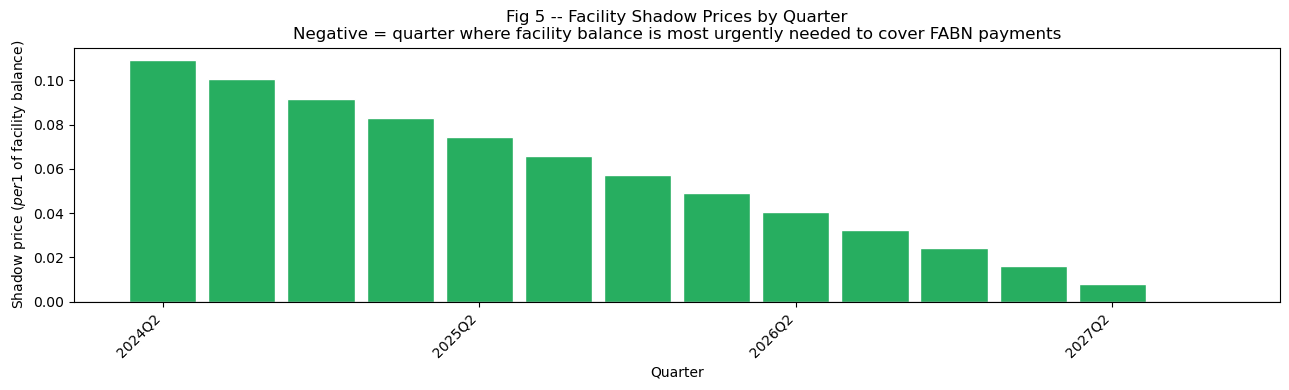

Tightest funding quarter: 2027Q3  (shadow price -0.0000)

  TABLE 2 -- NEAR-MISS BONDS
  Ranked by reduced cost: y_i - r*_hurdle (positive -> reservation price > market price).
  'Price gap': RC * MD * Price ($/100 face) -- value above market price to us.


,Rank,CUSIP,Sector,Rating,Book yield (%),Duration (yr),RBC theta_i (%),tau_i (bps),Reduced cost,Gap to entry (bps),Price gap ($/100)
0,1,13607GRZ9,Financials,AAA,5.038,2.612,0.158,6.5,-0.00280,28.0,-0.67
1,2,BT4580663,Financials,AAA,5.038,2.612,0.158,6.5,-0.00280,28.0,-0.67


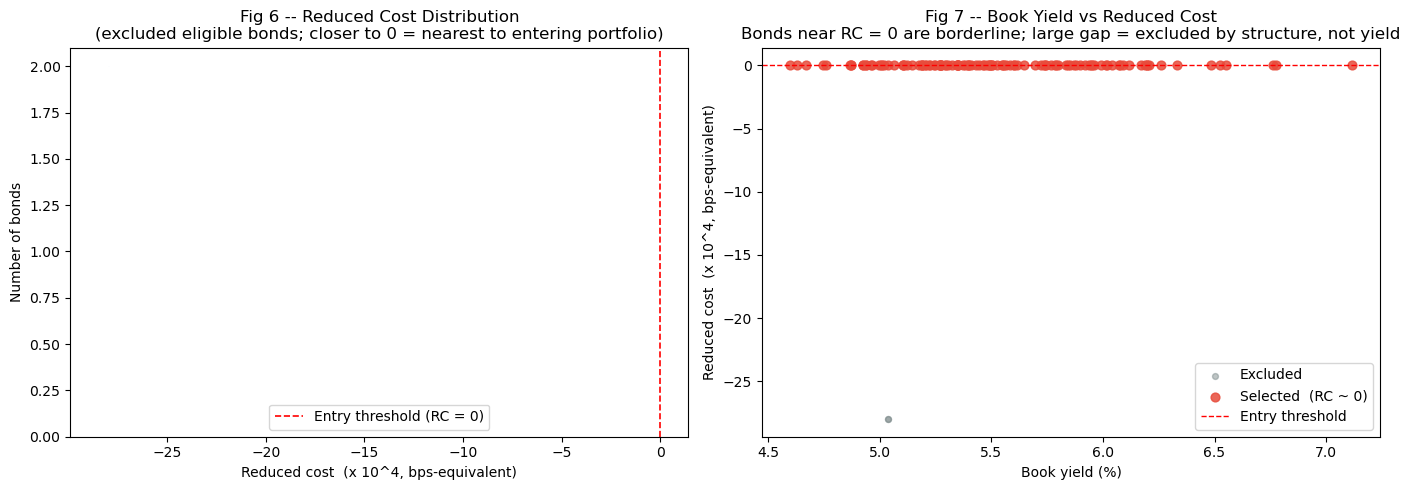

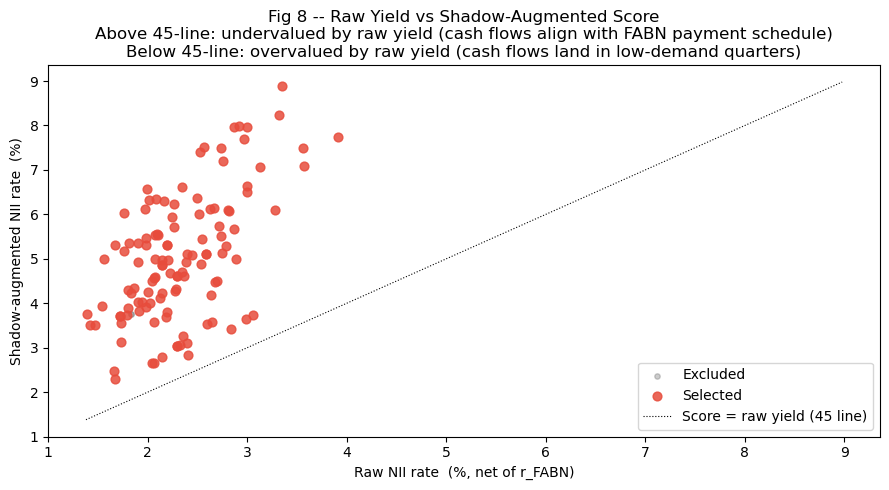


[Shadow score = book_yield_net + sum_q pi_facility[q] * CF_bond[q,i]]
Bonds above the 45-degree line contribute more than their yield implies because
their cash flows land in quarters where the lending facility needs them most.


In [48]:
# =============================================================================
# 3B. SHADOW PRICE ANALYSIS  --  always run after Section 3
# =============================================================================
if model.Status != GRB.OPTIMAL:
    print("Shadow price analysis requires an optimal solution -- skipping.")
else:
    # -- 1. Extract dual values (shadow prices) of all named constraints -------
    pi_budget    = model.getConstrByName("budget").Pi
    pi_dur_upper = model.getConstrByName("dur_upper").Pi
    pi_dur_lower = model.getConstrByName("dur_lower").Pi
    pi_shortfall = model.getConstrByName("pv_shortfall_limit").Pi
    pi_facility  = np.array([model.getConstrByName(f"facility_{q}").Pi for q in range(Q)])
    pi_issuer    = {iss: model.getConstrByName(f"conc_{iss}").Pi for iss in issuer_groups}

    # -- 2. Reduced costs of bond allocation variables h[i] -------------------
    rc = np.array([h[i].RC for i in range(N)])

    # -- 2b. Marginal $ with NO issuer/diversification caps -----------------
    #        Same exercise as the Budget shadow price, but relax ONLY the
    #        issuer concentration caps (conc_*).  KEEP the duration band and
    #        the PV-shortfall cap, so the duration-relief value that makes the
    #        budget dollar worth pi_budget is preserved -- only diversification
    #        is freed.  Re-solve and read the new budget dual.  The returned
    #        principal is reinvested by the model's facility block automatically
    #        (same basis as pi_budget); a sub-funding bond is never chosen at
    #        the margin, so the "reinvestment bucket" floor is implicit.
    _m2 = model.copy()
    _m2.Params.OutputFlag = 0
    for _iss in issuer_groups:
        _m2.getConstrByName(f"conc_{_iss}").RHS = GRB.INFINITY   # drop issuer caps ONLY
    _m2.optimize()
    if _m2.Status == GRB.OPTIMAL:
        pi_unconstr  = _m2.getConstrByName("budget").Pi
        _h2          = np.array([_m2.getVarByName(f"h[{i}]").X for i in range(N)])
        best_i       = int(np.argmax(_h2 - h_opt))      # where the freed dollar flows
        _best_status = "held" if h_opt[best_i] > 1.0 else "new (was capped out)"
    else:
        pi_unconstr  = float("nan"); best_i = 0; _best_status = "re-solve failed"

    # -- 3. TABLE 1: Constraint Shadow Price Report ---------------------------
    def _yn(v): return "Yes" if abs(v) > 1e-6 else "No"
    pd.set_option("display.max_colwidth", None)   # show full Reading text (no "..." truncation)

    t1 = pd.DataFrame([
        {
            "Constraint"   : "Budget  (Sum h_i = H)",
            "Shadow price" : f"${pi_budget:+,.4f} / $1",
            "Binding?"     : "Equality",
            "Reading"      : f"$1 more capital -> ${pi_budget:,.4f} more net NII",
        },
        {
            "Constraint"   : "Marginal $  (no issuer/diversification caps)",
            "Shadow price" : f"${pi_unconstr:+,.4f} / $1",
            "Binding?"     : "n/a",
            "Reading"      : (f"vs ${pi_budget:.4f} constrained -> dropping issuer caps is worth "
                              f"${pi_unconstr - pi_budget:+,.4f}/$1; freed $ -> {CUSIPS[best_i]} [{_best_status}]"),
        },
        {
            "Constraint"   : f"Duration upper  (<= {eps_D} yr x H)",
            "Shadow price" : f"${pi_dur_upper:+,.4f} / yr-$",
            "Binding?"     : _yn(pi_dur_upper),
            "Reading"      : (
                f"Binding -- widen band by 0.1 yr -> +${abs(pi_dur_upper)*0.1*H:,.0f} NII"
                if abs(pi_dur_upper) > 1e-6 else
                "Not binding -- portfolio fits naturally within upper limit"
            ),
        },
        {
            "Constraint"   : f"Duration lower  (<= {eps_D} yr x H)",
            "Shadow price" : f"${pi_dur_lower:+,.4f} / yr-$",
            "Binding?"     : _yn(pi_dur_lower),
            "Reading"      : (
                f"Binding -- widen band by 0.1 yr -> +${abs(pi_dur_lower)*0.1*H:,.0f} NII"
                if abs(pi_dur_lower) > 1e-6 else
                "Not binding -- portfolio fits naturally within lower limit"
            ),
        },
        {
            "Constraint"   : f"PV shortfall cap  (<= {phi_sf:.1%} PV_L)",
            "Shadow price" : f"${pi_shortfall:+,.4f} / $1",
            "Binding?"     : _yn(pi_shortfall),
            "Reading"      : (
                f"Binding -- $1M more tolerance -> +${abs(pi_shortfall)*1e6:,.0f} NII"
                if abs(pi_shortfall) > 1e-6 else
                "Not binding -- facility surplus comfortable"
            ),
        },
    ])
    print("=" * 68)
    print("  TABLE 1 -- CONSTRAINT SHADOW PRICE REPORT")
    print("=" * 68)
    display(t1)

    # -- 4. Binding issuer concentration caps ---------------------------------
    bind_iss = sorted(
        [(iss, pi) for iss, pi in pi_issuer.items() if abs(pi) > 1e-6],
        key=lambda x: abs(x[1]), reverse=True,
    )
    print(f"\nIssuer concentration caps: {len(bind_iss)} of {len(issuer_groups)} are binding.")
    if bind_iss:
        print("Top 10 binding issuers (optimizer wants more than the 5% cap allows):")
        display(pd.DataFrame([
            {
                "Issuer (6-char CUSIP)"   : iss,
                "Shadow price"            : f"${pi:+,.4f} / $1",
                "NII gain if cap +1pp ($)": f"${abs(pi) * 0.01 * H:,.0f}",
            }
            for iss, pi in bind_iss[:10]
        ]))

    # -- 5. Chart A: Facility quarter shadow prices ----------------------------
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(
        range(Q), pi_facility,
        color=["#e74c3c" if p < 0 else "#27ae60" for p in pi_facility],
        edgecolor="white", width=0.85,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(range(0, Q, 4))
    ax.set_xticklabels([str(qtr_idx[q]) for q in range(0, Q, 4)], rotation=45, ha="right")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Shadow price ($ per $1 of facility balance)")
    ax.set_title(
        "Fig 5 -- Facility Shadow Prices by Quarter\n"
        "Negative = quarter where facility balance is most urgently needed to cover FABN payments"
    )
    plt.tight_layout(); plt.show()

    tightest_q = int(np.argmin(pi_facility))
    print(f"Tightest funding quarter: {qtr_idx[tightest_q]}  "
          f"(shadow price {pi_facility[tightest_q]:.4f})")

    # -- 6. TABLE 2: Near-miss bonds (excluded, ranked by reduced cost) --------
    # post_fabn_mask bonds are forced to zero by the maturity rule -- skip them.
    eligible = ~post_fabn_mask
    excluded = (h_opt < 1.0) & eligible
    excl_idx = np.where(excluded)[0]
    order    = np.argsort(-rc[excl_idx])   # descending: least-negative RC first

    _pf = pipeline["fixed"].set_index("CUSIP")
    t2_rows = []
    for rank, pos in enumerate(order[:20]):
        i   = excl_idx[pos]
        cid = CUSIPS[i]
        t2_rows.append({
            "Rank"              : rank + 1,
            "CUSIP"             : cid,
            "Sector"            : str(_pf.loc[cid, "sector"]),
            "Rating"            : str(_pf.loc[cid, "rating_sp"]).strip(),
            "Book yield (%)"    : f"{book_yield[i]*100:.3f}",
            "Duration (yr)"     : f"{durs[i]:.3f}",
            "RBC theta_i (%)"   : f"{theta[i]*100:.3f}",
            "tau_i (bps)"       : f"{tau[i]*1e4:.1f}",
            "Reduced cost"      : f"{rc[i]:+.5f}",
            "Gap to entry (bps)": f"{abs(rc[i])*1e4:.1f}",
            "Price gap ($/100)" : f"{durs[i] * rc[i] * price[i]:+.2f}",
        })
    print("\n" + "=" * 68)
    print("  TABLE 2 -- NEAR-MISS BONDS")
    print("  Ranked by reduced cost: y_i - r*_hurdle (positive -> reservation price > market price).")
    print("  'Price gap': RC * MD * Price ($/100 face) -- value above market price to us.")
    print("=" * 68)
    display(pd.DataFrame(t2_rows))

    # -- 7. Chart B: RC distribution + book yield vs RC scatter ---------------
    rc_excl = rc[excl_idx]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: reduced cost distribution (all excluded eligible bonds)
    axes[0].hist(rc_excl * 1e4, bins=40, color="#3498db", edgecolor="white")
    axes[0].axvline(0, color="red", ls="--", lw=1.2, label="Entry threshold (RC = 0)")
    axes[0].set_xlabel("Reduced cost  (x 10^4, bps-equivalent)")
    axes[0].set_ylabel("Number of bonds")
    axes[0].set_title(
        "Fig 6 -- Reduced Cost Distribution\n"
        "(excluded eligible bonds; closer to 0 = nearest to entering portfolio)"
    )
    axes[0].legend()

    # Right: book yield vs reduced cost
    sel_mask = h_opt > 1.0
    axes[1].scatter(book_yield[excl_idx] * 100, rc_excl * 1e4,
                    alpha=0.5, color="#7f8c8d", s=18, label="Excluded")
    axes[1].scatter(book_yield[sel_mask] * 100, rc[sel_mask] * 1e4,
                    alpha=0.85, color="#e74c3c", s=40, label="Selected  (RC ~ 0)")
    axes[1].axhline(0, color="red", ls="--", lw=1.0, label="Entry threshold")
    axes[1].set_xlabel("Book yield (%)")
    axes[1].set_ylabel("Reduced cost  (x 10^4, bps-equivalent)")
    axes[1].set_title(
        "Fig 7 -- Book Yield vs Reduced Cost\n"
        "Bonds near RC = 0 are borderline; large gap = excluded by structure, not yield"
    )
    axes[1].legend()
    plt.tight_layout(); plt.show()

    # -- 8. Shadow-augmented facility fit score --------------------------------
    # For each bond compute the bonus value from its cash-flow timing:
    #   bonus_i = sum_q  pi_facility[q] * CF_bond[q, i]   (per $1 of h_i)
    # A positive bonus means the bond's payments fall in quarters where the FABN
    # needs liquidity most -- it is worth more than its raw yield implies.
    fac_bonus  = np.array([
        sum(float(pi_facility[q]) * float(qtr_bond_cf[q, i]) for q in range(Q))
        for i in range(N)
    ])
    shadow_nii = nii_rate + fac_bonus    # shadow-augmented NII rate

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(
        nii_rate[~sel_mask & eligible] * 100,
        shadow_nii[~sel_mask & eligible] * 100,
        alpha=0.4, color="grey", s=15, label="Excluded",
    )
    ax.scatter(
        nii_rate[sel_mask] * 100,
        shadow_nii[sel_mask] * 100,
        alpha=0.85, color="#e74c3c", s=40, label="Selected",
    )
    _lo = min(nii_rate[eligible].min(), shadow_nii[eligible].min()) * 100 * 0.99
    _hi = max(nii_rate[eligible].max(), shadow_nii[eligible].max()) * 100 * 1.01
    ax.plot([_lo, _hi], [_lo, _hi], "k:", lw=0.8, label="Score = raw yield (45 line)")
    ax.set_xlabel("Raw NII rate  (%, net of r_FABN)")
    ax.set_ylabel("Shadow-augmented NII rate  (%)")
    ax.set_title(
        "Fig 8 -- Raw Yield vs Shadow-Augmented Score\n"
        "Above 45-line: undervalued by raw yield (cash flows align with FABN payment schedule)\n"
        "Below 45-line: overvalued by raw yield (cash flows land in low-demand quarters)"
    )
    ax.legend()
    plt.tight_layout(); plt.show()

    print("\n[Shadow score = book_yield_net + sum_q pi_facility[q] * CF_bond[q,i]]")
    print("Bonds above the 45-degree line contribute more than their yield implies because")
    print("their cash flows land in quarters where the lending facility needs them most.")

In [56]:
# ---- Quick bond lookup: paste a CUSIP, get maturity / duration / price / yield ----
cusip = "TT3297450"     # <-- put your CUSIP here

_fx = pipeline["fixed"].set_index("CUSIP")
if cusip not in CUSIPS:
    print(f"{cusip} not in the optimizer universe (N={len(CUSIPS)} bonds).")
else:
    i   = CUSIPS.index(cusip)
    mat = pd.to_datetime(_fx.loc[cusip, "maturity"]).date()
    print(f"CUSIP        : {cusip}")
    print(f"Maturity     : {mat}")
    print(f"Duration     : {durs[i]:.3f} yrs (modified)")
    print(f"Price        : {price[i]:.3f}  (per 100 face)")
    print(f"Book yield   : {book_yield[i]*100:.3f}%")
    print(f"Net of r_FABN: {(book_yield[i]-r_FABN)*100:+.3f}%   (yield - {r_FABN*100:.3f}%)")
    # allocation context, if Section 3 has run:
    try:
        print(f"Held (h_opt) : ${h_opt[i]:,.0f}   ({h_opt[i]/H*100:.2f}% of budget)")
    except NameError:
        pass

CUSIP        : TT3297450
Maturity     : 2026-10-15
Duration     : 2.180 yrs (modified)
Price        : 105.698  (per 100 face)
Book yield   : 6.763%
Net of r_FABN: +3.558%   (yield - 3.205%)
Held (h_opt) : $25,000,000   (5.00% of budget)


---
## Section 3B-ii — Per-Bond Reservation Price (Shadow Price)

The LP implicitly computes a **hurdle yield** $r^*_i$ for every bond — the minimum yield the bond
must offer (given its duration, credit, and cash-flow timing) for the optimizer to want it.

$$r^*_i = y_i - RC_i$$

where $y_i$ is the bond's book yield and $RC_i$ is its reduced cost from the LP.

The **reservation price** (shadow price) is the PV of the bond's cash flows discounted at $r^*_i$:

$$P^*_i = \sum_t CF_{t,i}\,(1 + r^*_i)^{-t} \times 100$$

| Interpretation | Condition |
|---|---|
| Bond is **underpriced** for us (optimizer wants it) | $P^*_i > P^{mkt}_i$ (gap > 0) |
| Bond is **overpriced** for us (optimizer rejects it) | $P^*_i < P^{mkt}_i$ (gap < 0) |
| Bond is **at the margin** (just entering/leaving) | $P^*_i \approx P^{mkt}_i$ (gap ≈ 0) |

  TABLE 3 — PER-BOND RESERVATION PRICE (SHADOW PRICE)
  P*_i = PV(bond CFs at hurdle yield r*_i).  Gap = P* − Market Price.
  Gap > 0 → bond is cheap for us.  Gap < 0 → bond is expensive for us.
  Bonds with P* > P (underpriced for portfolio) : 0
  Bonds with P* ≈ P (at the margin)            : 1
  Bonds with P* < P (overpriced for portfolio)  : 118

  TOP 20 — highest shadow-price premium (bonds the optimizer values most):


,CUSIP,Sector,Rating,Mkt Price ($/100),Shadow Price P*,Gap (P*−P),Gap (%),Book Yield (%),Hurdle r* (%),Duration (yr),Selected
0,75951BAQ9,Financials,A+,90.260,90.259,-0.001,-0.00,5.834,5.834,2.326,YES
1,44891AAK3,Consumer Discretionary,A-,93.944,93.942,-0.002,-0.00,5.444,5.444,2.306,YES
2,48723RAC9,Financials,A+,95.055,95.038,-0.017,-0.02,5.740,5.740,2.696,YES
3,456837AH6,Financials,A-,96.680,96.644,-0.036,-0.04,5.992,5.992,2.660,YES
4,742718FG9,Consumer Staples,AA-,95.131,95.076,-0.055,-0.06,4.628,4.628,2.757,YES
5,66815M2R7,Financials,AA+,100.409,100.347,-0.062,-0.06,5.005,5.005,2.677,YES
6,00138EAY0,Financials,A,100.000,99.923,-0.077,-0.08,6.118,6.118,2.020,YES
7,BR4616800,Industrials,BBB+,91.609,91.532,-0.077,-0.08,6.197,6.197,2.285,YES
8,656029AG0,Financials,A,90.947,90.869,-0.078,-0.09,5.296,5.296,2.328,YES
9,13607HVE9,Financials,A,92.202,92.115,-0.087,-0.09,5.221,5.221,2.094,YES



  BOTTOM 20 — largest shadow-price discount (bonds furthest from entering):


,CUSIP,Sector,Rating,Mkt Price ($/100),Shadow Price P*,Gap (P*−P),Gap (%),Book Yield (%),Hurdle r* (%),Duration (yr),Selected
99,18977X2A5,Financials,A-,91.337,90.156,-1.181,-1.29,5.936,5.936,2.328,YES
100,46115HBB2,Financials,BBB+,94.072,92.887,-1.185,-1.26,6.260,6.260,2.919,YES
101,65540JAJ7,Financials,A+,97.509,96.315,-1.194,-1.22,5.494,5.494,2.907,YES
102,65540KAJ4,Financials,A+,97.509,96.315,-1.194,-1.22,5.494,5.494,2.907,YES
103,JK7097401,Financials,A,96.677,95.469,-1.208,-1.25,6.171,6.171,1.857,YES
104,BR5983126,Financials,A-,91.391,90.183,-1.208,-1.32,6.075,6.075,2.322,YES
105,233853AM2,Industrials,A-,95.961,94.731,-1.230,-1.28,5.844,5.844,2.697,YES
106,902613BB3,Financials,A-,98.494,97.261,-1.233,-1.25,6.527,6.527,1.843,YES
107,44891CCT8,Consumer Discretionary,A-,99.996,98.759,-1.237,-1.24,5.787,5.787,2.464,YES
108,931142CH4,Consumer Staples,AA,104.124,102.843,-1.281,-1.23,5.478,5.478,2.625,YES


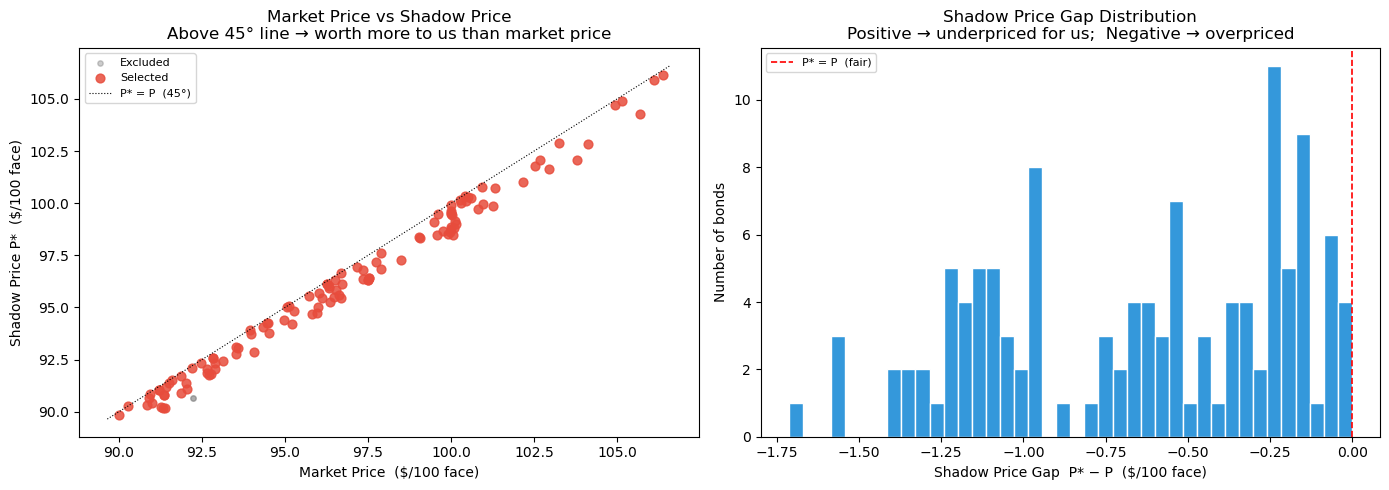


Shadow price gap stats (eligible bonds, $/100 face):
  Mean gap   : -0.654
  Median gap : -0.593
  Max (most underpriced) : -0.001  (bond 75951BAQ9)
  Min (most overpriced)  : -1.713  (bond 205887AF9)


In [50]:
# =============================================================================
# 3B-ii. PER-BOND RESERVATION PRICE (SHADOW PRICE)  --  always run after 3B
# =============================================================================
if model.Status == GRB.OPTIMAL:
    # -- 1. Hurdle yield and reservation price for every eligible bond ---------
    r_star = book_yield - rc                           # r*_i = y_i - RC_i
    P_star = np.full(N, np.nan)
    t_q_arr = np.array(t_quarters)
    for i in range(N):
        cfs = qtr_bond_cf[:, i]                        # per $1 face
        if cfs.sum() < 1e-12 or r_star[i] <= -1:
            continue
        P_star[i] = float((cfs * (1.0 + r_star[i]) ** (-t_q_arr)).sum()) * 100.0

    gap = P_star - price                               # $/100 face

    # -- 2. TABLE 3: full bond list sorted by gap ----------------------------
    _pf = pipeline["fixed"].set_index("CUSIP")
    t3_rows = []
    for i in range(N):
        if post_fabn_mask[i] or np.isnan(P_star[i]):
            continue
        cid = CUSIPS[i]
        t3_rows.append({
            "CUSIP"               : cid,
            "Sector"              : str(_pf.loc[cid, "sector"]),
            "Rating"              : str(_pf.loc[cid, "rating_sp"]).strip(),
            "Mkt Price ($/100)"   : round(price[i], 3),
            "Shadow Price P*"     : round(P_star[i], 3),
            "Gap (P*−P)"          : round(gap[i], 3),
            "Gap (%)"             : round(gap[i] / price[i] * 100, 2),
            "Book Yield (%)"      : round(book_yield[i] * 100, 3),
            "Hurdle r* (%)"       : round(r_star[i] * 100, 3),
            "Duration (yr)"       : round(durs[i], 3),
            "Selected"            : "YES" if h_opt[i] > 1.0 else "",
        })
    t3_df = pd.DataFrame(t3_rows).sort_values("Gap (P*−P)", ascending=False).reset_index(drop=True)

    n_pos = int((t3_df["Gap (P*−P)"] > 0.001).sum())
    n_neg = int((t3_df["Gap (P*−P)"] < -0.001).sum())
    n_par = len(t3_df) - n_pos - n_neg

    print("=" * 72)
    print("  TABLE 3 — PER-BOND RESERVATION PRICE (SHADOW PRICE)")
    print("  P*_i = PV(bond CFs at hurdle yield r*_i).  Gap = P* − Market Price.")
    print("  Gap > 0 → bond is cheap for us.  Gap < 0 → bond is expensive for us.")
    print("=" * 72)
    print(f"  Bonds with P* > P (underpriced for portfolio) : {n_pos}")
    print(f"  Bonds with P* ≈ P (at the margin)            : {n_par}")
    print(f"  Bonds with P* < P (overpriced for portfolio)  : {n_neg}")
    print(f"\n  TOP 20 — highest shadow-price premium (bonds the optimizer values most):")
    display(t3_df.head(20))
    print(f"\n  BOTTOM 20 — largest shadow-price discount (bonds furthest from entering):")
    display(t3_df.tail(20))

    # -- 3. Charts: Market Price vs Shadow Price + Gap distribution -----------
    elig_fin = ~post_fabn_mask & np.isfinite(P_star)
    P_e   = price[elig_fin]
    PS_e  = P_star[elig_fin]
    sel_e = h_opt[elig_fin] > 1.0
    gap_e = gap[elig_fin]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(P_e[~sel_e], PS_e[~sel_e], alpha=0.4, color="grey", s=15, label="Excluded")
    axes[0].scatter(P_e[sel_e],  PS_e[sel_e],  alpha=0.85, color="#e74c3c", s=40, label="Selected")
    _lo = min(P_e.min(), PS_e.min()) * 0.998
    _hi = max(P_e.max(), PS_e.max()) * 1.002
    axes[0].plot([_lo, _hi], [_lo, _hi], "k:", lw=0.8, label="P* = P  (45°)")
    axes[0].set_xlabel("Market Price  ($/100 face)")
    axes[0].set_ylabel("Shadow Price P*  ($/100 face)")
    axes[0].set_title("Market Price vs Shadow Price\nAbove 45° line → worth more to us than market price")
    axes[0].legend(fontsize=8)

    axes[1].hist(gap_e, bins=40, color="#3498db", edgecolor="white")
    axes[1].axvline(0, color="red", ls="--", lw=1.2, label="P* = P  (fair)")
    axes[1].set_xlabel("Shadow Price Gap  P* − P  ($/100 face)")
    axes[1].set_ylabel("Number of bonds")
    axes[1].set_title("Shadow Price Gap Distribution\nPositive → underpriced for us;  Negative → overpriced")
    axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

    # -- 4. Summary stats -----------------------------------------------------
    print(f"\nShadow price gap stats (eligible bonds, $/100 face):")
    print(f"  Mean gap   : {gap_e.mean():+.3f}")
    print(f"  Median gap : {np.median(gap_e):+.3f}")
    print(f"  Max (most underpriced) : {gap_e.max():+.3f}  (bond {CUSIPS[np.where(elig_fin)[0][np.argmax(gap_e)]]})")
    print(f"  Min (most overpriced)  : {gap_e.min():+.3f}  (bond {CUSIPS[np.where(elig_fin)[0][np.argmin(gap_e)]]})")
else:
    print("Reservation price analysis requires an optimal solution -- skipping.")

---
## Section 3C — Swap Overlay Analytics

Duration attribution and quarterly cash-flow contribution from the swap overlay.


C:\Users\lalot\AppData\Local\Temp\ipykernel_27520\4237398316.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


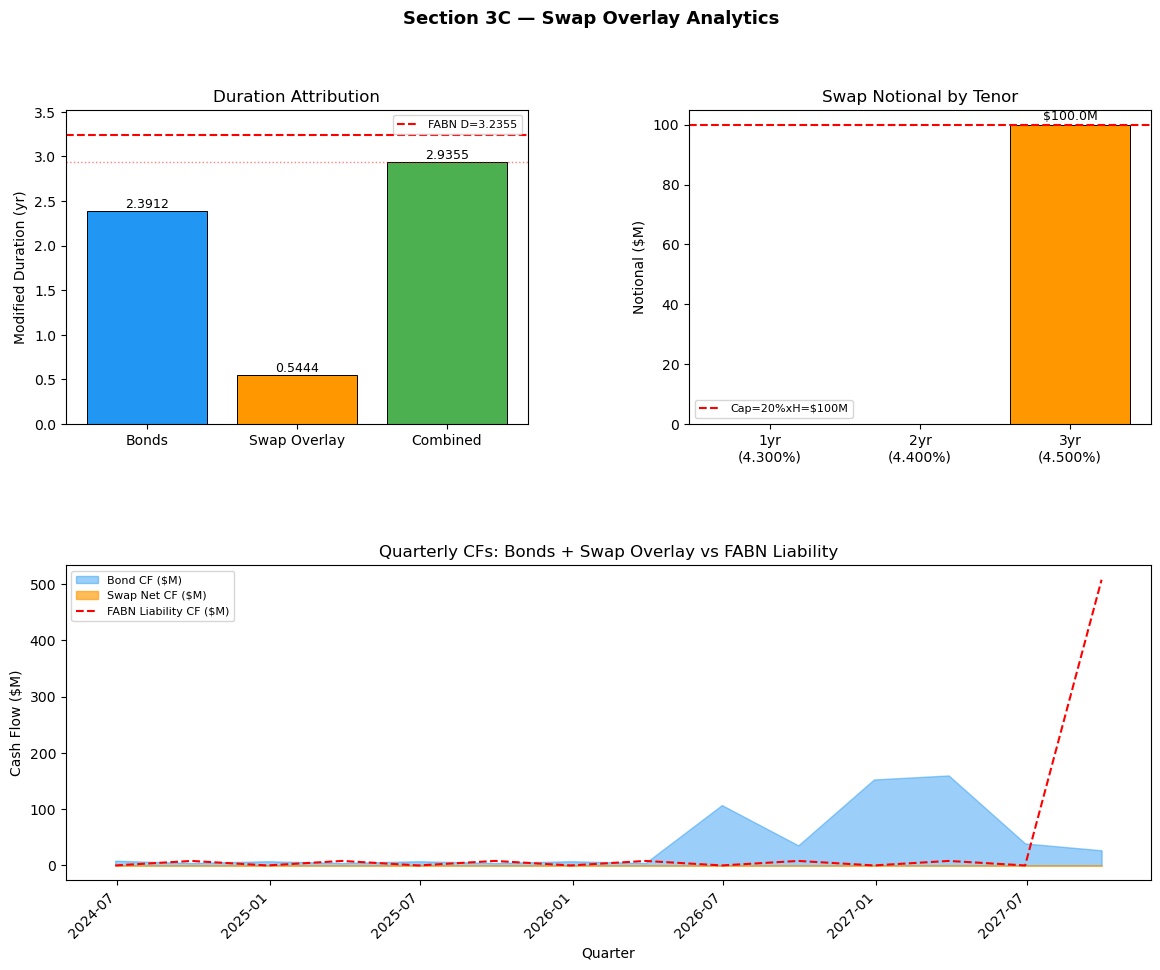

Saved: fig_swap_overlay.png


In [51]:
# =============================================================================
# 3C. SWAP OVERLAY ANALYTICS  --  Duration attribution & CF contribution
# =============================================================================
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

if use_swaps and K > 0 and v_opt.sum() > 1.0:
    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

    # 3C-1: Duration attribution (stacked bar)
    ax1 = fig.add_subplot(gs[0, 0])
    dur_bond_contrib = float(sum(durs[i] * h_opt[i] for i in range(N))) / H
    dur_swap_contrib = float(sum(D_swap[k] * v_opt[k] for k in range(K))) / H
    vals   = [dur_bond_contrib, dur_swap_contrib, D_eff]
    colors = ["#2196F3", "#FF9800", "#4CAF50"]
    labels = ["Bonds", "Swap Overlay", "Combined"]
    bars = ax1.bar(labels, vals, color=colors, edgecolor="k", linewidth=0.7)
    ax1.axhline(D_FABN, color="red", linestyle="--", linewidth=1.5, label=f"FABN D={D_FABN:.4f}")
    ax1.axhline(D_FABN + eps_D, color="red", linestyle=":", linewidth=1, alpha=0.5)
    ax1.axhline(D_FABN - eps_D, color="red", linestyle=":", linewidth=1, alpha=0.5)
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=9)
    ax1.set_ylabel("Modified Duration (yr)")
    ax1.set_title("Duration Attribution")
    ax1.legend(fontsize=8)
    ax1.set_ylim(0, max(vals) * 1.20)

    # 3C-2: Swap notional by tenor
    ax2 = fig.add_subplot(gs[0, 1])
    tenors_str = [f"{swap_maturities[k]:.0f}yr\n({swap_rates_k[k]:.3%})" for k in range(K)]
    bars2 = ax2.bar(tenors_str, v_opt / 1e6, color="#FF9800", edgecolor="k", linewidth=0.7)
    cap_line = swap_cap_pct * H / 1e6
    ax2.axhline(cap_line, color="red", linestyle="--", linewidth=1.5,
                label=f"Cap={swap_cap_pct:.0%}xH=${cap_line:.0f}M")
    for bar, val in zip(bars2, v_opt / 1e6):
        if val > 0.5:
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f"${val:.1f}M", ha="center", va="bottom", fontsize=9)
    ax2.set_ylabel("Notional ($M)")
    ax2.set_title("Swap Notional by Tenor")
    ax2.legend(fontsize=8)

    # 3C-3: Quarterly cash flows (bonds + swap vs liability) across all quarters
    ax3 = fig.add_subplot(gs[1, :])
    q_dates = [optimization_date + pd.DateOffset(months=3*(q+1)) for q in range(Q)]
    cf_bonds_q = np.array([float(sum(qtr_bond_cf[q, i] * h_opt[i] for i in range(N)))
                            for q in range(Q)])
    cf_swap_q  = np.array([float(sum(cf_swap[k, q] * v_opt[k] for k in range(K)))
                            for q in range(Q)])
    cf_liab_q  = np.array([float(qtr_fabn_cf[q]) for q in range(Q)])
    ax3.fill_between(q_dates, cf_bonds_q / 1e6, alpha=0.45, color="#2196F3",
                     label="Bond CF ($M)")
    ax3.fill_between(q_dates, cf_swap_q / 1e6,  alpha=0.65, color="#FF9800",
                     label="Swap Net CF ($M)")
    ax3.plot(q_dates, cf_liab_q / 1e6, color="red", linewidth=1.5, linestyle="--",
             label="FABN Liability CF ($M)")
    ax3.set_xlabel("Quarter")
    ax3.set_ylabel("Cash Flow ($M)")
    ax3.set_title("Quarterly CFs: Bonds + Swap Overlay vs FABN Liability")
    ax3.legend(fontsize=8)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax3.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha="right")

    plt.suptitle("Section 3C — Swap Overlay Analytics", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print("Saved: fig_swap_overlay.png")
else:
    print("Swap overlay not active (use_swaps=False or optimizer allocated zero notional).")


---
## Section 4 — Analytics

In [52]:
# =============================================================================
# 4. ANALYTICS  --  always run
# =============================================================================
fixed_df = pipeline["fixed"].set_index("CUSIP")
selected = h_opt > 1.0
w        = h_opt[selected] / h_opt[selected].sum()

# -- 4A. Objective decomposition table ----------------------------------------
sap_summary = pd.DataFrame({
    "Component": ["Statutory NII", "  - coupon income", "  - amortization",
                  "Savings income", "Capital cost (lambda*RBC)",
                  "Liquidity penalty", "Turnover cost", "SAP OBJECTIVE"],
    "Value ($)": [nii_val, coupon_val, amort_val, savings_val,
                  -capital_cost_val, -liq_val, -turnover_val, sap_val],
})
display(sap_summary)

# -- 4B. Portfolio analytics --------------------------------------------------
analytics = pd.DataFrame({
    "Metric": ["Bonds selected (h>$1)", "Wtd avg book yield (%)",
               "Wtd avg coupon yield (%)", "Wtd avg amortization (bps)",
               "Wtd avg OAS spread (bps)", "Wtd avg duration (yrs)",
               "Wtd avg RBC factor (%)", "Statutory earnings / req. capital"],
    "Value": [int(selected.sum()),
              f"{(book_yield[selected]*w).sum()*100:.2f}",
              f"{(coupon_inc[selected]*w).sum()*100:.2f}",
              f"{(amort_inc[selected]*w).sum()*1e4:+.1f}",
              f"{(spread[selected]*w).sum()*1e4:.1f}",
              f"{(durs[selected]*w).sum():.4f}",
              f"{(theta[selected]*w).sum()*100:.3f}",
              f"{earn_per_cap:.4f}"],
})
display(analytics)

# -- 4C. Allocation table -----------------------------------------------------
alloc_df = pd.DataFrame({
    "CUSIP": CUSIPS,
    "Sector": [str(fixed_df.loc[c, "sector"]) for c in CUSIPS],
    "Rating": [str(fixed_df.loc[c, "rating_sp"]).strip() for c in CUSIPS],
    "h_opt ($)": h_opt,
    "Book yield (%)": book_yield * 100,
    "Coupon (%)": coupon_inc * 100,
    "Amort (bps)": amort_inc * 1e4,
    "Duration (yr)": durs,
    "RBC f_i (%)": theta * 100,
    "tau (bps)": tau * 1e4,
})
alloc_nonzero = alloc_df[alloc_df["h_opt ($)"] > 1.0].sort_values("h_opt ($)", ascending=False).reset_index(drop=True)
print(f"Non-zero allocations: {len(alloc_nonzero)} / {N} bonds")
display(alloc_nonzero)

,Component,Value ($)
0,Statutory NII,1.293742e+07
1,- coupon income,2.361184e+07
2,- amortization,5.350575e+06
3,Savings income,1.325118e+07
4,Capital cost (lambda*RBC),-8.693329e+05
5,Liquidity penalty,-0.000000e+00
6,Turnover cost,-6.474685e+06
7,SAP OBJECTIVE,1.894958e+07


,Metric,Value
0,Bonds selected (h>$1),117
1,Wtd avg book yield (%),5.79
2,Wtd avg coupon yield (%),4.72
3,Wtd avg amortization (bps),+107.0
4,Wtd avg OAS spread (bps),63.4
5,Wtd avg duration (yrs),2.3912
6,Wtd avg RBC factor (%),0.773
7,Statutory earnings / req. capital,2.2323


Non-zero allocations: 117 / 303 bonds


,CUSIP,Sector,Rating,h_opt ($),Book yield (%),Coupon (%),Amort (bps),Duration (yr),RBC f_i (%),tau (bps)
0,48723RAC9,Financials,A+,2.500000e+07,5.739825,3.419073,232.075228,2.695852,0.657,78.901688
1,ZH5526616,Government,AA+,2.500000e+07,5.869257,5.200491,66.876582,2.282014,0.271,16.839686
2,ZB0794709,Financials,AA+,2.500000e+07,5.898981,4.904267,99.471426,2.653619,0.271,52.045279
3,TT3297450,Energy,A-,2.500000e+07,6.763342,7.213949,-45.060766,2.180346,1.016,54.873318
4,456837AH6,Financials,A-,2.500000e+07,5.991659,4.085643,190.601573,2.660075,1.016,63.094746
...,...,...,...,...,...,...,...,...,...,...
112,AM6439740,Financials,BBB+,1.650165e+06,5.951189,4.567348,138.384091,2.631448,1.261,99.651221
113,BR4616800,Industrials,BBB+,1.650165e+06,6.196831,2.619830,357.700077,2.285217,1.261,347.127466
114,83368JKF6,Financials,BBB-,1.650165e+06,6.332458,4.421832,191.062550,2.156260,2.168,133.175188
115,205887AF9,Consumer Staples,BBB-,1.650165e+06,7.115750,6.863963,25.178639,2.150112,2.168,276.485265


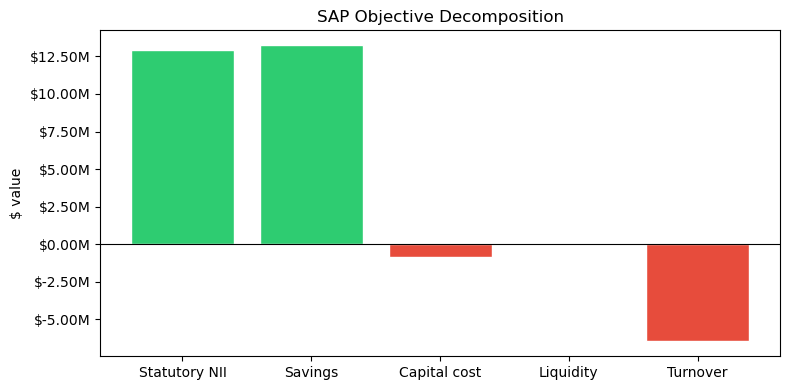

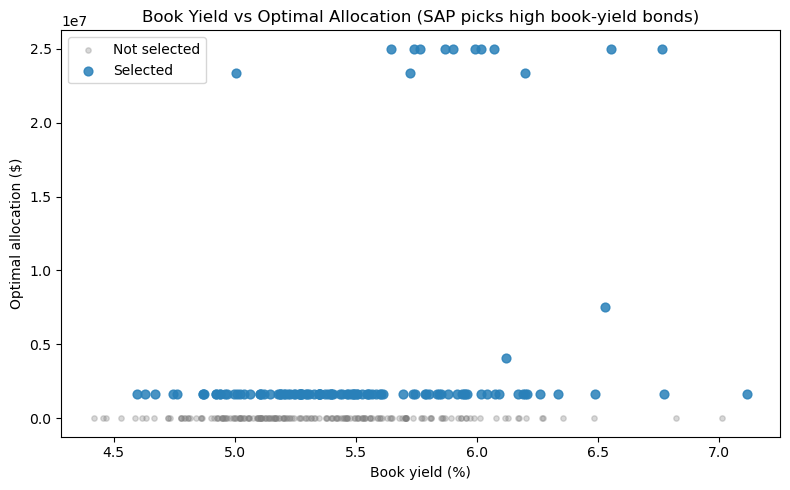

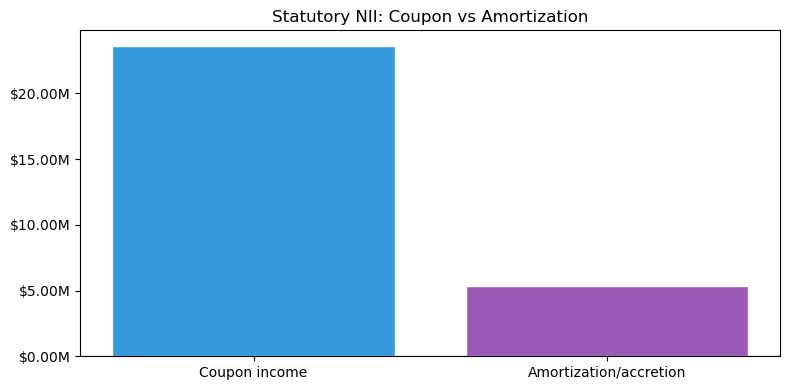

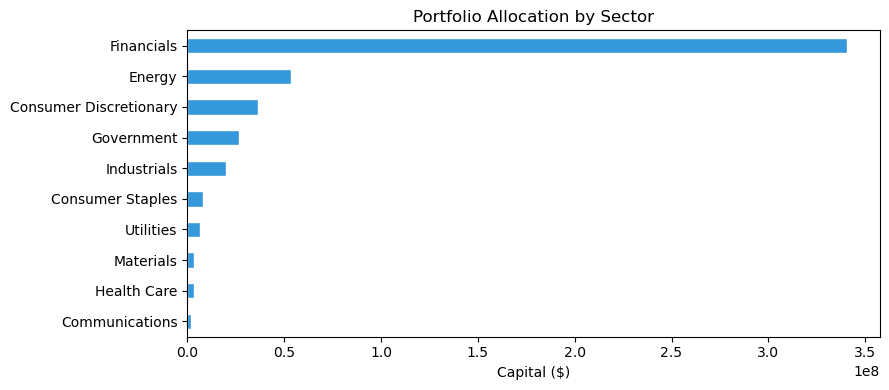

In [53]:
# -- 4D. Charts ---------------------------------------------------------------
# Fig 1: SAP objective decomposition
fig, ax = plt.subplots(figsize=(8, 4))
comp = [nii_val, savings_val, -capital_cost_val, -liq_val, -turnover_val]
lab  = ["Statutory NII", "Savings", "Capital cost", "Liquidity", "Turnover"]
ax.bar(lab, comp, color=["#2ecc71" if v >= 0 else "#e74c3c" for v in comp], edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("SAP Objective Decomposition"); ax.set_ylabel("$ value")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.2f}M"))
plt.tight_layout(); plt.show()

# Fig 2: Book yield vs allocation (selected bonds)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(book_yield[~selected]*100, h_opt[~selected], alpha=0.3, color="grey", s=15, label="Not selected")
ax.scatter(book_yield[selected]*100,  h_opt[selected],  alpha=0.85, color="#2980b9", s=40, label="Selected")
ax.set_xlabel("Book yield (%)"); ax.set_ylabel("Optimal allocation ($)")
ax.set_title("Book Yield vs Optimal Allocation (SAP picks high book-yield bonds)")
ax.legend(); plt.tight_layout(); plt.show()

# Fig 3: Coupon vs amortization contribution of NII (selected bonds)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(["Coupon income", "Amortization/accretion"], [coupon_val, amort_val],
       color=["#3498db", "#9b59b6"], edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Statutory NII: Coupon vs Amortization")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.2f}M"))
plt.tight_layout(); plt.show()

# Fig 4: Sector allocation
sector_alloc = {}
for i, c in enumerate(CUSIPS):
    s = str(fixed_df.loc[c, "sector"]); sector_alloc[s] = sector_alloc.get(s, 0.0) + h_opt[i]
ss = pd.Series(sector_alloc); ss = ss[ss > 0].sort_values()
fig, ax = plt.subplots(figsize=(9, max(4, len(ss)*0.4)))
ss.plot(kind="barh", ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Portfolio Allocation by Sector"); ax.set_xlabel("Capital ($)")
plt.tight_layout(); plt.show()

Sweeping cost_of_capital -- 20 LP solves ...
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Done.


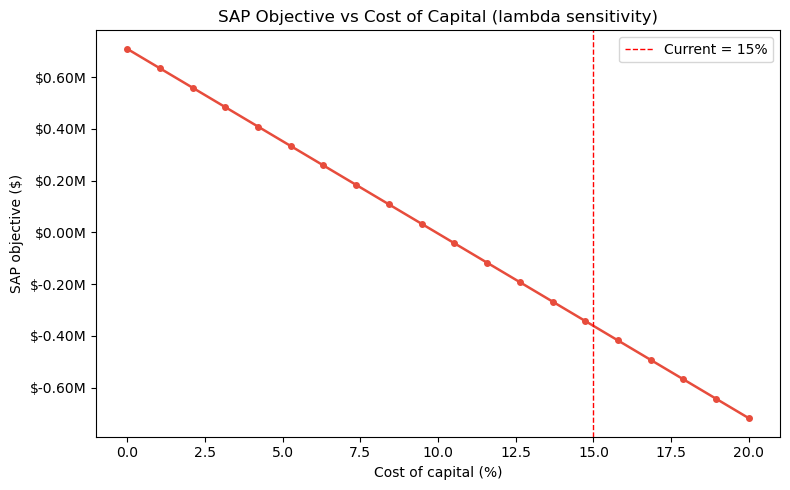

In [54]:
# -- 4E. Capital-cost sensitivity: SAP objective vs cost_of_capital -----------
# Re-solves the model for a sweep of cost_of_capital values; all else held fixed.
def _solve_sap(coc=cost_of_capital, eta_=eta, eps_D_=eps_D, delta_=delta):
    lam = coc * RBC_bar
    m = gp.Model("sap_sens"); m.Params.LogToConsole = 0; m.Params.OutputFlag = 0
    h2 = m.addVars(N, lb=0.0)
    for i in range(N):
        if post_fabn_mask[i]: h2[i].ub = 0.0
    dp = m.addVar(lb=0.0); dn = m.addVar(lb=0.0)
    tp = m.addVars(N, lb=0.0); tm = m.addVars(N, lb=0.0)
    B2 = m.addVars(Q, lb=0.0); sn = m.addVars(Q, lb=0.0)
    nii = gp.quicksum(nii_rate[i]*h2[i] for i in range(N))
    rbc = gp.quicksum(theta[i]*h2[i] for i in range(N))
    txn = gp.quicksum(tau[i]*(tp[i]+tm[i]) for i in range(N))
    liq = eta_ * gp.quicksum(df_q[q]*sn[q] for q in range(Q))
    sav = r_save * dt_q * gp.quicksum(B2[q] for q in range(Q-1))
    m.setObjective(nii - lam*rbc - txn - liq + sav, GRB.MAXIMIZE)
    m.addConstr(gp.quicksum(h2[i] for i in range(N)) == H)
    m.addConstr(gp.quicksum(durs[i]*h2[i] for i in range(N)) - D_FABN*H == dp - dn)
    m.addConstr(dp <= eps_D_*H); m.addConstr(dn <= eps_D_*H)
    for i in range(N):
        m.addConstr(h2[i] - h_curr[i] == tp[i] - tm[i])
    for iss, bidx in issuer_groups.items():
        m.addConstr(gp.quicksum(h2[i] for i in bidx) <= delta_*H)
    for q in range(Q):
        cfa = gp.quicksum(qtr_bond_cf[q, i]*h2[i] for i in range(N)); cfl = float(qtr_fabn_cf[q])
        if q == 0: m.addConstr(B2[q] - sn[q] == cfa - cfl)
        else:      m.addConstr(B2[q] - sn[q] == (1.0 + r_save*dt_q)*B2[q-1] + cfa - cfl)
    m.addConstr(gp.quicksum(df_q[q]*sn[q] for q in range(Q)) <= phi_sf*PV_liability)
    m.optimize()
    return m.ObjVal if m.Status == GRB.OPTIMAL else float("nan")

coc_range = np.linspace(0.0, 0.20, 20)
print("Sweeping cost_of_capital -- 20 LP solves ...")
sap_coc = [_solve_sap(coc=c) for c in coc_range]
print("Done.")
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(coc_range*100, sap_coc, "o-", color="#e74c3c", linewidth=1.8, markersize=4)
ax.axvline(cost_of_capital*100, color="red", linestyle="--", linewidth=1.0,
           label=f"Current = {cost_of_capital:.0%}")
ax.set_xlabel("Cost of capital (%)"); ax.set_ylabel("SAP objective ($)")
ax.set_title("SAP Objective vs Cost of Capital (lambda sensitivity)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.2f}M"))
ax.legend(); plt.tight_layout(); plt.show()